## Predicting Manufacturing Efficiency Using Sensor and Network Data

### Author: Eric Meyer

### Capstone Project – MS in Data Analytics, Northwest Missouri State University

## Importing Needed Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading Data Into Environment

### Check for data summary and description stats

In [2]:
# Load the dataset
file_path = "manufacturing_6G_dataset.csv"
df = pd.read_csv(file_path)

# Display basic info
df_info = df.info()

# Get shape and first few rows
df_shape = df.shape
df_head = df.head()

# Get column names and data types
df_columns = df.dtypes

# Get summary statistics
df_summary = df.describe(include='all')

df_shape, df_head, df_columns, df_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Timestamp                      100000 non-null  object 
 1   Machine_ID                     100000 non-null  int64  
 2   Operation_Mode                 100000 non-null  object 
 3   Temperature_C                  100000 non-null  float64
 4   Vibration_Hz                   100000 non-null  float64
 5   Power_Consumption_kW           100000 non-null  float64
 6   Network_Latency_ms             100000 non-null  float64
 7   Packet_Loss_%                  100000 non-null  float64
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64
 9   Production_Speed_units_per_hr  100000 non-null  float64
 10  Predictive_Maintenance_Score   100000 non-null  float64
 11  Error_Rate_%                   100000 non-null  float64
 12  Efficiency_Status              

((100000, 13),
              Timestamp  Machine_ID Operation_Mode  Temperature_C  \
 0  2024-01-01 00:00:00          39           Idle      74.137590   
 1  2024-01-01 00:01:00          29         Active      84.264558   
 2  2024-01-01 00:02:00          15         Active      44.280102   
 3  2024-01-01 00:03:00          43         Active      40.568502   
 4  2024-01-01 00:04:00           8           Idle      75.063817   
 
    Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  Packet_Loss_%  \
 0      3.500595              8.612162           10.650542       0.207764   
 1      3.355928              2.268559           29.111810       2.228464   
 2      2.079766              6.144105           18.357292       1.639416   
 3      0.298238              4.067825           29.153629       1.161021   
 4      0.345810              6.225737           34.029191       4.796520   
 
    Quality_Control_Defect_Rate_%  Production_Speed_units_per_hr  \
 0                       7.751261    

### Check for how clean data is

In [3]:
# Shape of dataset
print("Rows and columns:", df.shape)

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Percentage of missing data
missing_percent = df.isnull().mean() * 100
print("\n% Missing values per column:")
print(missing_percent)

# Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Data types
print("\nData types:")
print(df.dtypes)

# Summary statistics (for numeric columns)
print("\nDescriptive statistics:")
print(df.describe())

# Unique values (helps find inconsistency in categorical columns)
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Rows and columns: (100000, 13)

Missing values per column:
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

% Missing values per column:
Timestamp                        0.0
Machine_ID                       0.0
Operation_Mode                   0.0
Temperature_C                    0.0
Vibration_Hz                     0.0
Power_Consumption_kW             0.0
Network_Latency_ms               0.0
Packet_Loss_%                    0.0
Quality_Control_Defect_Rate_%    0.0
Production_Speed_units_per_hr    0.0
Predictive_Maintenance_Score     0.0
Error_Rate_%                     0.0

## Cleaning Process

### Creating clean copy of data

In [4]:
# Load data
file_path = "manufacturing_6G_dataset.csv"
df = pd.read_csv(file_path)

# Copy original for safety
df_clean = df.copy()

### Inspecting for missing data and duplicates

In [5]:

missing_values = df.isnull().sum()
print ("\nMissing Values per Column:")
print(missing_values)
print()
duplicates = df_clean.duplicated().sum()
print("Duplicated Rows:", duplicates)

# Drop if any
df_clean.drop_duplicates(inplace=True)


Missing Values per Column:
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

Duplicated Rows: 0


### Make sure timestamp is proper formatting

In [6]:
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'], errors='coerce')
print("Converted Timestamp dtype:", df_clean['Timestamp'].dtype)

Converted Timestamp dtype: datetime64[ns]


### Checking data types and fixing if needed

In [7]:
# Confirm data types
print(df_clean.dtypes)

# Fixing known numeric columns
numeric_cols = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%',
    'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
    'Predictive_Maintenance_Score', 'Error_Rate_%'
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

Timestamp                        datetime64[ns]
Machine_ID                                int64
Operation_Mode                           object
Temperature_C                           float64
Vibration_Hz                            float64
Power_Consumption_kW                    float64
Network_Latency_ms                      float64
Packet_Loss_%                           float64
Quality_Control_Defect_Rate_%           float64
Production_Speed_units_per_hr           float64
Predictive_Maintenance_Score            float64
Error_Rate_%                            float64
Efficiency_Status                        object
dtype: object


### Checking data for any outliers

In [8]:
print(df_clean[numeric_cols].describe())

# Flag extreme outliers (> 3 std devs)
z_scores = (df_clean[numeric_cols] - df_clean[numeric_cols].mean()) / df_clean[numeric_cols].std()
outliers = (np.abs(z_scores) > 3).sum()
print("Potential Outliers by Column:\n", outliers)

       Temperature_C   Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  \
count  100000.000000  100000.000000         100000.000000       100000.000000   
mean       60.041458       2.549959              5.745929           25.555620   
std        17.323238       1.414127              2.451271           14.120758   
min        30.000138       0.100011              1.500183            1.000025   
25%        45.031596       1.323214              3.627318           13.355118   
50%        60.033597       2.549441              5.755460           25.536079   
75%        74.967217       3.776459              7.860267           37.796372   
max        89.998979       4.999974              9.999889           49.999917   

       Packet_Loss_%  Quality_Control_Defect_Rate_%  \
count  100000.000000                  100000.000000   
mean        2.493418                       5.008806   
std         1.443273                       2.883666   
min         0.000026                       0.00044

### Getting final row and column count

In [9]:
print("Final shape:", df_clean.shape)

Final shape: (100000, 13)


### Exporting clean CSV to own file

In [10]:
df_clean.to_csv("cleaned_manufacturing_6G_dataset.csv", index=False)
print("Clean dataset saved to cleaned_manufacturing_6G_dataset.csv")

Clean dataset saved to cleaned_manufacturing_6G_dataset.csv


## EDA Process

### Showing Stats of Data Again

In [11]:
print("\nDescriptive statistics:")
display(df.describe(include='all'))


Descriptive statistics:


,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
count,100000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,100000,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,2024-03-10 10:23:00,NaN,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,1,NaN,70054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77825
mean,NaN,25.499330,NaN,60.041458,2.549959,5.745929,25.555620,2.493418,5.008806,275.916324,0.499385,7.504100,NaN
std,NaN,14.389439,NaN,17.323238,1.414127,2.451271,14.120758,1.443273,2.883666,130.096892,0.288814,4.335896,NaN
min,NaN,1.000000,NaN,30.000138,0.100011,1.500183,1.000025,0.000026,0.000449,50.000375,0.000003,0.000112,NaN
25%,NaN,13.000000,NaN,45.031596,1.323214,3.627318,13.355118,1.245026,2.521591,162.873618,0.248166,3.750148,NaN
50%,NaN,25.000000,NaN,60.033597,2.549441,5.755460,25.536079,2.487667,5.003569,276.648922,0.499209,7.504145,NaN
75%,NaN,38.000000,NaN,74.967217,3.776459,7.860267,37.796372,3.741252,7.506127,388.812761,0.748810,11.273189,NaN


### Looking at Data Distribution for Numerical Fields


Histograms for numeric features:


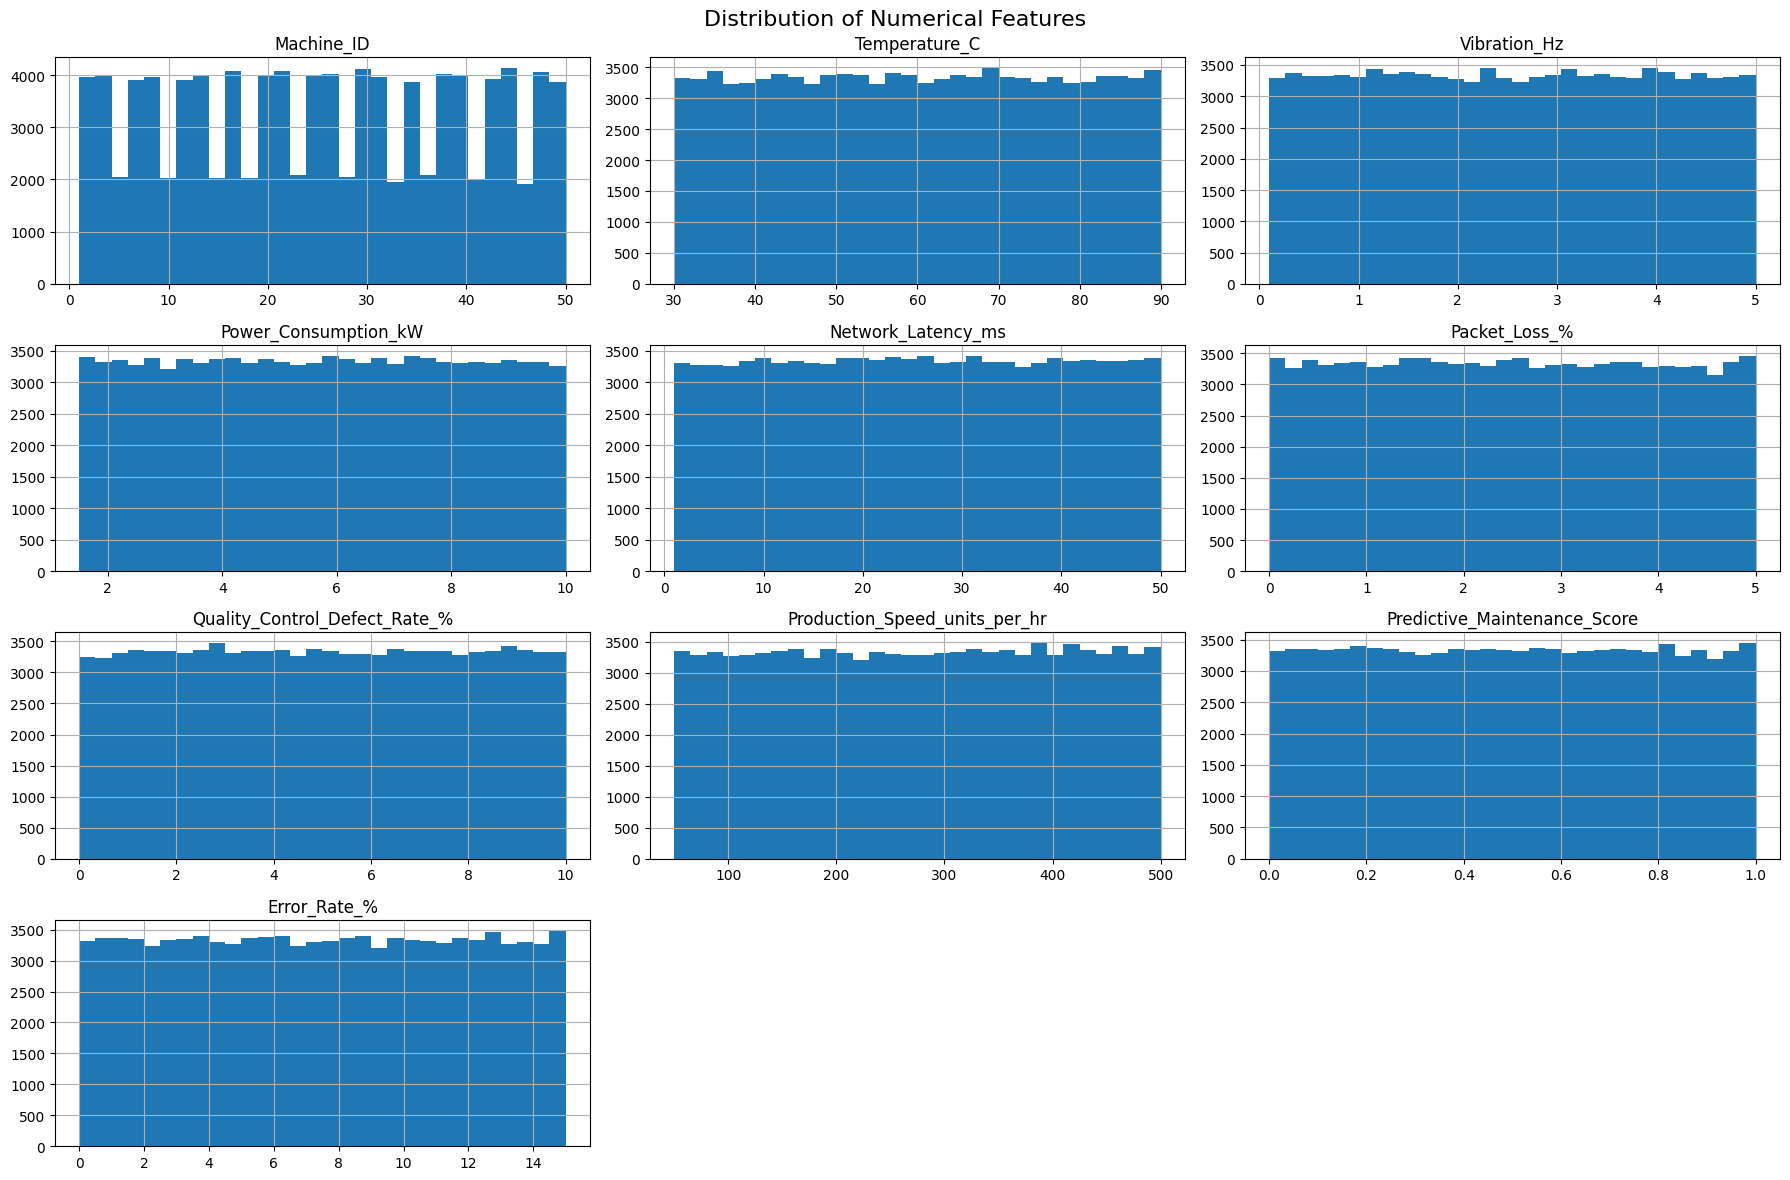

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

print("\nHistograms for numeric features:")
df[numerical_cols].hist(figsize=(18, 12), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Looking at Data Distribution for Categorial Fields

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print("\nValue counts for categorical features:")
for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

# Bar plots for categorical features
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Value counts for categorical features:

Timestamp value counts:
Timestamp
2024-03-10 10:23:00    1
2024-03-10 10:22:00    1
2024-03-10 10:21:00    1
2024-03-10 10:20:00    1
2024-03-10 10:19:00    1
                      ..
2024-01-01 00:04:00    1
2024-01-01 00:03:00    1
2024-01-01 00:02:00    1
2024-01-01 00:01:00    1
2024-01-01 00:00:00    1
Name: count, Length: 100000, dtype: int64

Operation_Mode value counts:
Operation_Mode
Active         70054
Idle           20057
Maintenance     9889
Name: count, dtype: int64

Efficiency_Status value counts:
Efficiency_Status
Low       77825
Medium    19189
High       2986
Name: count, dtype: int64


C:\Users\Lexi\AppData\Local\Temp\ipykernel_25296\3435582640.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2')


###